## **Figure-4**

In [1]:
import pandas as pd
import polars as pl
import sys
import sqlite3
from collections import defaultdict
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker



sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


In [3]:
names = dict(exp='Experimental',
             silico='in-silico',
             bruker='timsTOF, 2024',
             panhuman='PanHuman\n2014',
             diatracer='Direct')

condition = dict(orig='Initial', refined='Reference-based') # if change refined also need to change format_for_plot

In [4]:
# Use default mpl color cycle
default_colors = mpl.rcParams['axes.prop_cycle'].by_key()['color']

condition_palette = {
    condition['orig']: default_colors[0],
    condition['refined']: default_colors[1],
}


In [5]:
condition_palette_extended = {
    condition['orig']: default_colors[0],
    condition['refined'] + '_5ngLib': "#FFB77E",
    condition['refined'] + '_25ngLib': "#FF7F0E",   # Lightest Orange
    condition['refined'] + '_100ngLib' :  '#B85B00'  # Darkest Orange
}


In [6]:
def format_for_plot(rslts, condition_palette_extended=condition_palette_extended):
    ids = pd.DataFrame(rslts).map(lambda x: len(x) if isinstance(x, set) else np.nan ).melt(var_name='Library', value_name='# Peptide Precursors', ignore_index=False).reset_index(names='FullCondition').dropna()
    ids['Condition'] = ids["FullCondition"].str.replace(r"^(Reference-based).*", r"\1", regex=True)
    ids["point_color"] = ids["FullCondition"].map(condition_palette_extended)
    return ids


---

---

# **Load Data**

### **Identification Rates**

In [7]:
diann = { n:defaultdict(dict) for n in names.values() }
osw = { n:defaultdict(dict) for n in names.values() }

##### **DIA-NN Results**

In [8]:
# Bruker data
diann[names['bruker']][condition['orig']] = getPrecursorSetDiann("../../results/Dilutions-K562-Bruker-Lib/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv")
diann[names['bruker']][condition['refined'] + '_25ngLib'] = getPrecursorSetDiann("../../results/Dilutions-Bruker-Refined-Analysis/diann/1ng/25ng_lib/report.tsv")
diann[names['bruker']][condition['refined'] + '_5ngLib'] = getPrecursorSetDiann("../../results/Dilutions-Bruker-Refined-Analysis/diann/1ng/5ng_lib/report.tsv")
diann[names['bruker']][condition['refined'] + '_100ngLib'] = getPrecursorSetDiann("../../results/Dilutions-Bruker-Refined-Analysis/diann/1ng/100ng_lib/report.tsv")


# Silico data
diann[names['silico']][condition['orig']] = getPrecursorSetDiann("../../results/Dilutions-PeptDeep-NoMods-Lib/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv")
diann[names['silico']][condition['refined'] + '_25ngLib' ] = getPrecursorSetDiann("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/1ng/25ng_lib/report.tsv")
diann[names['silico']][condition['refined'] + '_5ngLib' ] = getPrecursorSetDiann("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/1ng/5ng_lib/report.tsv")
diann[names['silico']][condition['refined'] + '_100ngLib' ] = getPrecursorSetDiann("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/1ng/100ng_lib/report.tsv")


# DiaTracer data
diann[names['diatracer']][condition['orig']] = getPrecursorSetDiann("../../results/Dilutions-diaTracer/diann/1ng/report.tsv")
diann[names['diatracer']][condition['refined'] + '_100ngLib' ] = getPrecursorSetDiann("../../results/Dilutions-K562-diaTracer-Refinement/diann/1ng/100ng_lib/report.tsv")
diann[names['diatracer']][condition['refined'] + '_5ngLib' ] = getPrecursorSetDiann("../../results/Dilutions-K562-diaTracer-Refinement/diann/1ng/5ng_lib/report.tsv")
diann[names['diatracer']][condition['refined'] + '_25ngLib' ] = getPrecursorSetDiann("../../results/Dilutions-K562-diaTracer-Refinement/diann/1ng/25ng_lib/report.tsv")


# Experimental data
diann[names['exp']][condition['orig']] = getPrecursorSetDiann("../../results/Dilutions-K562-Exp-Lib/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv")
diann[names['exp']][condition['refined'] + '_25ngLib' ] = getPrecursorSetDiann("../../results/Dilutions-Exp-Refined-Analysis/diann/1ng/25ng_lib/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['refined'] + '_5ngLib' ] = getPrecursorSetDiann("../../results/Dilutions-Exp-Refined-Analysis/diann/1ng/5ng_lib/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['refined'] + '_100ngLib' ] = getPrecursorSetDiann("../../results/Dilutions-Exp-Refined-Analysis/diann/1ng/100ng_lib/report.tsv", infer_schema_length=1000)



# PanHuman data
diann[names['panhuman']][condition['orig']] = getPrecursorSetDiann("../../results/Dilutions-K562-PanHuman-Library/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv")
diann[names['panhuman']][condition['refined'] + '_25ngLib'] = getPrecursorSetDiann("../../results/Dilutions-PanHuman-Refined-Analysis/diann/1ng/25ng_lib/report.tsv", infer_schema_length=1000)
diann[names['panhuman']][condition['refined'] + '_5ngLib'] = getPrecursorSetDiann("../../results/Dilutions-PanHuman-Refined-Analysis/diann/1ng/5ng_lib/report.tsv", infer_schema_length=1000)
diann[names['panhuman']][condition['refined'] + '_100ngLib'] = getPrecursorSetDiann("../../results/Dilutions-PanHuman-Refined-Analysis/diann/1ng/100ng_lib/report.tsv", infer_schema_length=1000)

../../results/Dilutions-K562-Bruker-Lib/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv
../../results/Dilutions-Bruker-Refined-Analysis/diann/1ng/25ng_lib/report.tsv
../../results/Dilutions-Bruker-Refined-Analysis/diann/1ng/5ng_lib/report.tsv
../../results/Dilutions-Bruker-Refined-Analysis/diann/1ng/100ng_lib/report.tsv
../../results/Dilutions-PeptDeep-NoMods-Lib/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv
../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/1ng/25ng_lib/report.tsv
../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/1ng/5ng_lib/report.tsv
../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/1ng/100ng_lib/report.tsv
../../results/Dilutions-diaTracer/diann/1ng/report.tsv
../../results/Dilutions-K562-diaTracer-Refinement/diann/1ng/100ng_lib/report.tsv
../../results/Dilutions-K562-diaTracer-Refinement/diann/1ng/5ng_lib/report.tsv
../../results/Dilutions-K562-diaTracer-Refinement/diann

#### **OSW Results**

In [9]:
# Bruker data
osw[names['bruker']][condition['orig']] = getPrecursorSet_oswpq("../../results/Dilutions-K562-Bruker-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw[names['bruker']][condition['refined'] + '_25ngLib'] = getPrecursorSet_oswpq("../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw[names['bruker']][condition['refined'] + '_5ngLib'] = getPrecursorSet_oswpq("../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw[names['bruker']][condition['refined'] + '_100ngLib'] = getPrecursorSet_oswpq("../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")


# Silico data
osw[names['silico']][condition['orig']] = getPrecursorSet_oswpq("../../results/Dilutions-PeptDeep-NoMods-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['silico']][condition['refined'] + '_25ngLib'] = getPrecursorSet_oswpq("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['silico']][condition['refined'] + '_5ngLib'] = getPrecursorSet_oswpq("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['silico']][condition['refined'] + '_100ngLib'] = getPrecursorSet_oswpq("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")



# DiaTracer data
osw[names['diatracer']][condition['orig']] = getPrecursorSet("../../results/Dilutions-diaTracer/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_LDA/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.parquet")
osw[names['diatracer']][condition['refined'] + '_25ngLib'] = getPrecursorSet("../../results/Dilutions-K562-diaTracer-Refinement/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/25ng_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.parquet")
osw[names['diatracer']][condition['refined'] + '_5ngLib'] = getPrecursorSet("../../results/Dilutions-K562-diaTracer-Refinement/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/5ng_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.parquet")
osw[names['diatracer']][condition['refined'] + '_100ngLib'] = getPrecursorSet("../../results/Dilutions-K562-diaTracer-Refinement/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/100ng_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.parquet")


# Experimental data
osw[names['exp']][condition['orig']] = getPrecursorSet_oswpq("../../results/Dilutions-K562-Exp-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['exp']][condition['refined'] + '_25ngLib'] = getPrecursorSet_oswpq("../../results/Dilutions-Exp-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw[names['exp']][condition['refined'] + '_5ngLib'] = getPrecursorSet_oswpq("../../results/Dilutions-Exp-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw[names['exp']][condition['refined'] + '_100ngLib'] = getPrecursorSet_oswpq("../../results/Dilutions-Exp-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")


# PanHuman data
osw[names['panhuman']][condition['orig']] = getPrecursorSet_oswpq("../../results/Dilutions-K562-PanHuman-Library/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['panhuman']][condition['refined'] + '_25ngLib'] = getPrecursorSet_oswpq("../../results/Dilutions-PanHuman-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['panhuman']][condition['refined'] + '_5ngLib'] = getPrecursorSet_oswpq("../../results/Dilutions-PanHuman-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['panhuman']][condition['refined'] + '_100ngLib'] = getPrecursorSet_oswpq("../../results/Dilutions-PanHuman-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")

../../results/Dilutions-K562-Bruker-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq
../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq
../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq
../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq
../../results/Dilutions-PeptDeep-NoMods-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/
../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/
../../results/Dilutions-PeptDe

In [10]:
ids_diann = format_for_plot(diann)
ids_osw = format_for_plot(osw)

#### **Load Chromatographic Data**

In [11]:
ng_25_chromatograms = pd.read_pickle("ng_25_chromatogram.pkl")
ng_1_chromatograms = pd.read_pickle("ng_1_chromatogram.pkl")

In [12]:
prec = 'QILGVIDK'
chg = 2

In [13]:
ng_1_full_feature_refined = pd.read_parquet("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq", columns=['MODIFIED_SEQUENCE', 'DELTA_RT', 'EXP_RT', 'PRECURSOR_CHARGE', 'SCORE_MS2_PEAK_GROUP_RANK', 'SCORE_MS2_PEP', 'LEFT_WIDTH', 'RIGHT_WIDTH'])
ng_1_full_feature_refined = ng_1_full_feature_refined[(ng_1_full_feature_refined['MODIFIED_SEQUENCE'] == prec) & 
                                        (ng_1_full_feature_refined['PRECURSOR_CHARGE'] == chg) &
                                        (ng_1_full_feature_refined['SCORE_MS2_PEAK_GROUP_RANK'] == 1)].iloc[0]

ng_1_full_feature_orig = pd.read_parquet("../../results/Dilutions-PeptDeep-NoMods-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/precursors_features.parquet", columns=['MODIFIED_SEQUENCE', 'DELTA_RT', 'EXP_RT', 'PRECURSOR_CHARGE', 'SCORE_MS2_PEAK_GROUP_RANK', 'SCORE_MS2_PEP', 'LEFT_WIDTH', 'RIGHT_WIDTH'])
ng_1_full_feature_orig = ng_1_full_feature_orig[(ng_1_full_feature_orig['MODIFIED_SEQUENCE'] == prec) & 
                                        (ng_1_full_feature_orig['PRECURSOR_CHARGE'] == chg) &
                                        (ng_1_full_feature_orig['SCORE_MS2_PEAK_GROUP_RANK'] == 1)].iloc[0]

ng_25_full_feature = pd.read_parquet("../../results/Dilutions-PeptDeep-NoMods-Lib/osw/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021/pyprophet_LDA_XGBoost/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021.oswpq/precursors_features.parquet", columns=['MODIFIED_SEQUENCE', 'DELTA_RT', 'EXP_RT', 'PRECURSOR_CHARGE', 'SCORE_MS2_PEAK_GROUP_RANK', 'SCORE_MS2_PEP', 'LEFT_WIDTH', 'RIGHT_WIDTH'])

ng_25_full_feature = ng_25_full_feature[(ng_25_full_feature['MODIFIED_SEQUENCE'] == prec) & 
                                        (ng_25_full_feature['PRECURSOR_CHARGE'] == chg) &
                                        (ng_25_full_feature['SCORE_MS2_PEAK_GROUP_RANK'] == 1)].iloc[0]

---

In [14]:
np.random.seed(40)
def plotIDs(data, ax, title, show_xlabel=False, font_size_small=8, font_size_medium=9, font_size_large=10, ):    
    # Updated kwargs with better error bar color
    kwargs = dict(estimator='median', palette=condition_palette, errorbar=None, 
                  edgecolor="white", alpha=0.5)
    # Absolute values (left axis)
    sns.barplot(
        data=data,
        x="Library", y="# Peptide Precursors", hue="Condition", ax=ax, legend=False, **kwargs)

    sns.swarmplot(data=data, x='Library', y='# Peptide Precursors', hue='Condition', ax=ax, 
                  legend=False, palette=condition_palette, dodge=True, s=6, 
                  linewidth=1, edgecolor='black')

    # recolor swarm points using FullCondition palette
    collections = ax.collections[-len(data["Library"].unique()) * len(data["Condition"].unique()):]

    grouped = data.groupby(["Library", "Condition"], sort=False)

    for coll, ((lib, cond), subset) in zip(collections, grouped):
        colors = subset["point_color"].values
        coll.set_facecolors(colors)

    ax.set_ylabel("# Peptide Precursors", fontsize=font_size_large)
    if not show_xlabel:
        ax.set_xticks([])
        ax.set_xlabel("")
        ax.tick_params(labelsize=font_size_small)
    else:
        ax.set_xlabel("Library", fontsize=font_size_large)
        ax.tick_params('x', labelsize=font_size_small, rotation=30)
        for l in ax.get_xticklabels():
            if l.get_text() == 'in-silico':
                l.set_fontstyle('italic')

    ax.tick_params('y', labelsize=font_size_small)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{int(val / 1000)}K'))
    
    ax.set_title(title, fontsize=font_size_large)
    ax.grid(True, axis="y", alpha=0.3, zorder=-2)
    ax.set_ylim(0, 28000)
  

In [15]:
def createChromatograms(ax1, 
                        ax2, 
                        xlim=(4050, 4250), 
                        ylim=(0, 4000), 
                        line_width=1.0,
                        vspan_color='yellow', 
                        vspan_alpha=0.3, 
                        vline_color = 'tab:blue',
                        vline_color2 = 'tab:orange',
                        text_y=3500,
                        font_size_small=7,
                        font_size_medium=8,
                        font_size_large=10,
                        labelpad=3):
    
    # --- Data Retrieval (Assuming these variables are available in the scope) ---
    target_sample_pep_orig_lib = ng_1_full_feature_orig['SCORE_MS2_PEP']
    target_sample_pep_refined_lib = ng_1_full_feature_refined['SCORE_MS2_PEP']
    reference_sample_pep_orig_lib = ng_25_full_feature['SCORE_MS2_PEP']
    
    # --- Plot Reference Sample (ax1) ---
    ng_25_chromatograms.plot(
        backend='ms_matplotlib',
        x='rt',
        y='intensity',
        by='annotation',
        kind='chromatogram',
        title='Reference Sample (High Sensitivity)',
        xlabel='',
        canvas=ax1,
        line_width=line_width,
        show_plot=False,
        title_font_size=font_size_large,
        xaxis_label_font_size=font_size_large,
        yaxis_label_font_size=font_size_large, 
        xaxis_labelpad=labelpad,
        yaxis_labelpad=labelpad,
        xaxis_tick_font_size=font_size_medium,
        yaxis_tick_font_size=font_size_medium,
        grid=False,
        legend_config=dict(show=True)
    )
    ax1.set_xlim(*xlim)
    ax1.set_ylim(*ylim)
    ax1.axvspan(ng_25_full_feature['LEFT_WIDTH'] - 8, ng_25_full_feature['RIGHT_WIDTH'], color=vspan_color, alpha=vspan_alpha)

    ax1.axvline(ng_25_full_feature['EXP_RT'] - ng_25_full_feature['DELTA_RT'], color=vline_color, lw=2, ls='--') # Reduced lw from 3 to 2
    ax1.text(
        ng_25_full_feature['EXP_RT'] - ng_25_full_feature['DELTA_RT'] - 10,
        text_y,
        'Initial RT',
        ha='right',
        fontsize=font_size_medium,
        color='white',
        bbox=dict(
            facecolor=vline_color,
            edgecolor='black',
            boxstyle='round,pad=0.2'
        )
    )

    # --- Plot Target Sample (ax2) ---
    ng_1_chromatograms.plot(
        backend='ms_matplotlib',
        x='rt',
        y='intensity',
        by='annotation',
        kind='chromatogram',
        xlabel='Retention Time (RT)',
        title='Target Sample (Low Sensitivity)',
        canvas=ax2,
        line_width=line_width,
        show_plot=False,
        title_font_size=font_size_large,
        xaxis_label_font_size=font_size_large,
        yaxis_label_font_size=font_size_large, 
        xaxis_labelpad=labelpad,
        yaxis_labelpad=labelpad,
        xaxis_tick_font_size=font_size_medium,
        yaxis_tick_font_size=font_size_medium,
        grid=False,
        legend_config=dict(show=False)
    )
    ax2.set_xlim(*xlim)
    ax2.set_ylim(*ylim)
    ax2.axvspan(ng_1_full_feature_refined['LEFT_WIDTH'], ng_1_full_feature_refined['RIGHT_WIDTH'], color=vspan_color, alpha=vspan_alpha)
    ax2.axvline(ng_1_full_feature_refined['EXP_RT'] - ng_1_full_feature_refined['DELTA_RT'], color=vline_color2, lw=2, ls='--') # Reduced lw from 3 to 2

    ax2.text(
        ng_1_full_feature_refined['EXP_RT'] - ng_1_full_feature_refined['DELTA_RT'] - 15,
        text_y/2,
        'Reconstructed\nRT',
        ha='right',
        fontsize=font_size_medium,
        color='black',
        bbox=dict(
            facecolor=vline_color2,
            edgecolor='black',
            boxstyle='round,pad=0.2'
        )
    )

    ax2.axvline(ng_1_full_feature_refined['EXP_RT'] - ng_1_full_feature_orig['DELTA_RT'], color=vline_color, lw=2, ls='--') # Reduced lw from 3 to 2
    ax2.text(
        ng_1_full_feature_refined['EXP_RT'] - ng_1_full_feature_orig['DELTA_RT'] - 10,
        text_y-1000,
        'Initial RT',
        ha='right',
        fontsize=font_size_medium,
        color='white',
        bbox=dict(
            facecolor=vline_color,
            edgecolor='black',
            boxstyle='round,pad=0.2'
        )
    )

    ax2.text(
        xlim[1] - 5,
        text_y,
        f'Initial PEP: {target_sample_pep_orig_lib:.2%}\nReconstructed PEP: {target_sample_pep_refined_lib:.2%}',
        ha='right',
        fontsize=font_size_small,
        color='black',
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            boxstyle='round,pad=0.2'
        )
    )

    ax1.text(
        xlim[1] - 5,
        text_y+30,
        f'Initial PEP: {reference_sample_pep_orig_lib:.2%}',
        ha='right',
        fontsize=font_size_small, 
        color='black',
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            boxstyle='round,pad=0.2'
        )
    )

    # --- Move legend to figure level ---
    handles, labels = ax1.get_legend().legend_handles, [t.get_text() for t in ax1.get_legend().get_texts()]
    
    # Assuming 'fig' is available in the global scope (common when calling plt.figure() before this function)
    fig = ax1.figure 

    ax2.legend(
        handles, labels,
        ncol=3,
        loc='lower center',
        bbox_to_anchor=(0.5,-0.55),
        fontsize=font_size_small
    )
    ax1.get_legend().remove()

    ax2.grid(axis='x')
    ax1.grid(axis='x')

    ax1.tick_params(axis='x', labelbottom=False)

    bbox = ax2.get_position()
    x_center = (bbox.x0 + bbox.x1) / 2

    ax2.text(
        (xlim[0] + xlim[1]) / 2,
        -1200,
        f'{prec}/{chg}',
        ha='center',
        va='bottom',
        fontsize=font_size_large, 
        color='black',
        bbox=dict(facecolor='lightgrey', edgecolor='none', boxstyle='round,pad=0.2')
    )

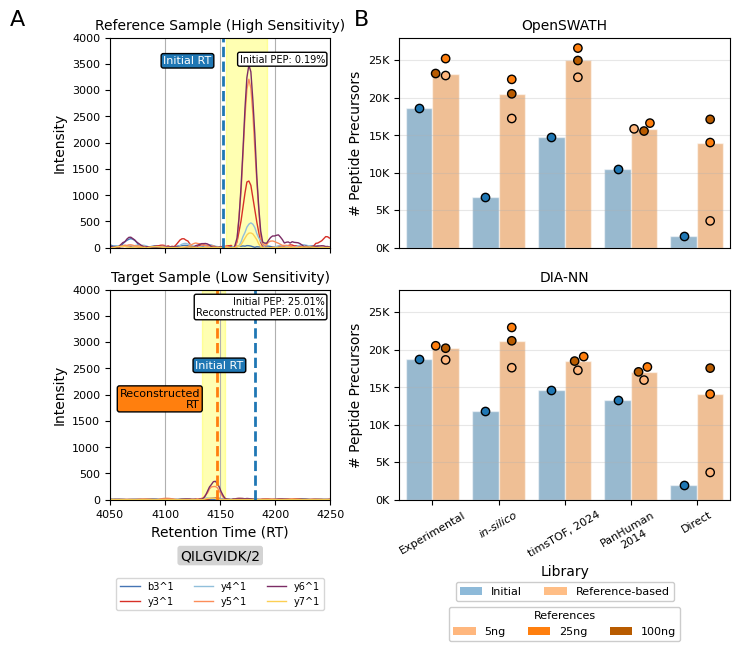

In [16]:
fig = plt.figure(figsize=(8, 6))

# --- Top Section: 2x2 grid with asymmetric widths ---
gs = gridspec.GridSpec(
    2, 2, 
    figure=fig, 
    hspace=0.2, 
    wspace=0.25,
    width_ratios=[2, 3]  # Left column is wider than the right
)

# Big plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[0, 1])
ax4 = fig.add_subplot(gs[1, 1])


createChromatograms(ax1, ax2)
plotIDs(ids_osw, title='OpenSWATH', ax=ax3, show_xlabel=False)
plotIDs(ids_diann, title='DIA-NN', ax=ax4, show_xlabel=True)


    

    # Custom legend (one per condition) - placed at bottom
handles = [
    plt.matplotlib.patches.Patch(facecolor=condition_palette[c], label=c,  alpha=0.5)
    for c in ids_diann['Condition'].unique()
]
leg = ax4.legend(handles=handles, loc='lower center', ncol=len(handles),
               fontsize=8, facecolor='white', framealpha=1,
               bbox_to_anchor=(0.5, -0.51))
ax4.add_artist(leg)

handles2 = [
    plt.matplotlib.patches.Patch(facecolor="#FFB77E", label='5ng'),
    plt.matplotlib.patches.Patch(facecolor="#FF7F0E", label='25ng'),
    plt.matplotlib.patches.Patch(facecolor="#B85B00", label='100ng')
]


ax4.legend(handles=handles2, labels=[f'{i}ng' for i in [5, 25, 100] ], loc='lower center', ncol=len(handles2),
               fontsize=8, facecolor='white', framealpha=1, title='References', title_fontsize=8,
               bbox_to_anchor=(0.5, -0.7))

fig.text(0, 0.9, 'A', fontsize=16) 
fig.text(0.43, 0.9, 'B', fontsize=16) 
plt.savefig("figure4.png", dpi=300, bbox_inches='tight')


In [17]:
ids_osw['Software'] = 'OSW'
ids_diann['Software'] = 'DIANN'

In [18]:
ids_tog = pd.concat([ids_osw, ids_diann])

In [19]:
def tmp(df):
    old_value = df[df['Condition'] == condition['orig']]['# Peptide Precursors'].mean()
    new_value = df[df['Condition'] == condition['refined']]['# Peptide Precursors'].mean()
    increase = new_value - old_value
    percent = (increase / old_value) * 100
    return percent
    
    

stat = ids_tog.groupby(['Library', 'Software'], group_keys=False).apply(tmp, include_groups=False)

In [20]:
stat

Library         Software
Direct          DIANN       516.710457
                OSW         648.035406
Experimental    DIANN         5.418089
                OSW          27.376616
PanHuman\n2014  DIANN        27.768945
                OSW          52.570465
in-silico       DIANN        74.545918
                OSW         199.785622
timsTOF, 2024   DIANN        24.751099
                OSW          67.844547
dtype: float64